### Single Image

Informal retail class Id: 0


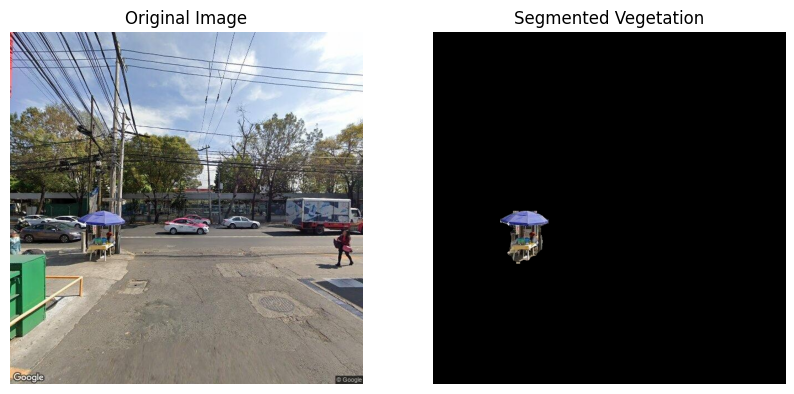

Number of street stalls detected: 1


In [23]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from alivestreets.features.street_stall_segmentator import StreetStallSegmentator

#Substitute by the path of an image containing a street stall
img_path = "./tests/data/trajectory_streetview_demo/network_images_sidewalks/point_167/sidewalk_views/sidewalk_right.jpg"

img= np.array(Image.open(img_path))

stall_segmentator = StreetStallSegmentator()

n_stalls = stall_segmentator.compute(img, debug = True)
print(f"Number of street stalls detected: {n_stalls}")

### Street Network analysis.

Number of points  371


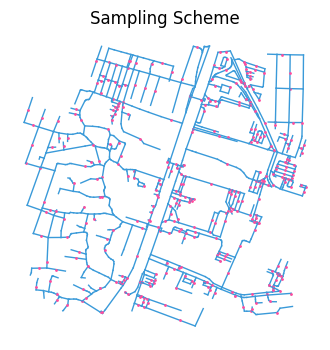

In [24]:
network_path = "/Users/legariapena.j/Documents/alivestreets-local-copy/alivestreets/tests/tests/data/trajectory_streetview_demo/network.geojson"

from alivestreets.sampling.street_sampler import StreetSampler
import os

street_sampler = StreetSampler(120)
street_sampler.open_streets(network_path)

street_sampler.sample_streets_no_intersections()

street_sampler.draw_sampling_scheme(width = 4, height = 4)

print("Number of points ", len(street_sampler.get_all_sampling_points()))
images_path = "/Users/legariapena.j/Documents/alivestreets-local-copy/alivestreets/tests/tests/data/trajectory_streetview_demo/network_images_sidewalks"

path_points_dictionary = os.path.join(images_path, "point_dictionaries.jsonl")


In [25]:
import json

from alivestreets.sampling.geometry import PointDistanceCalculator
with open(path_points_dictionary, "r") as f:
    data = [json.loads(line) for line in f if line.strip()]

sampling_points = street_sampler.get_all_sampling_points()
point_distance_calculator = PointDistanceCalculator()

data_by_coord = {}
for i, point_dictionary in enumerate(data):
    key = (round(point_dictionary["longitude"], 7), round(point_dictionary["latitude"], 7))
    if key not in data_by_coord:
        data_by_coord[key] = []
    data_by_coord[key].append(i)

aligned_point_dictionaries = []
alignment_distance_m = []
unmatched_points = []
used_data_indices = set()

for point in sampling_points:
    key = (round(point[0], 7), round(point[1], 7))
    match_idx = None

    candidate_indices = data_by_coord.get(key, [])
    for idx in candidate_indices:
        if idx not in used_data_indices:
            match_idx = idx
            break

    # If exact rounding-based match fails, use nearest unused metadata point.
    if match_idx is None:
        best_idx = None
        best_dist = float("inf")
        for idx, point_dictionary in enumerate(data):
            if idx in used_data_indices:
                continue
            dist_m = point_distance_calculator.get_distance(
                point[1], point[0],
                point_dictionary["latitude"], point_dictionary["longitude"]
            )
            if dist_m < best_dist:
                best_dist = dist_m
                best_idx = idx

        if best_idx is not None and best_dist <= 25:
            match_idx = best_idx

    if match_idx is None:
        aligned_point_dictionaries.append(None)
        alignment_distance_m.append(np.nan)
        unmatched_points.append(point)
    else:
        used_data_indices.add(match_idx)
        point_dictionary = data[match_idx]
        aligned_point_dictionaries.append(point_dictionary)
        dist_m = point_distance_calculator.get_distance(
            point[1], point[0],
            point_dictionary["latitude"], point_dictionary["longitude"]
        )
        alignment_distance_m.append(float(dist_m))

matched_distances = [d for d in alignment_distance_m if np.isfinite(d)]

In [30]:
street_stall_counts = []
from tqdm import tqdm

for point_dict in tqdm(aligned_point_dictionaries):
    if(point_dict is None):
        street_stall_counts.append(None)
        continue
    img_paths = point_dict.get("view_paths", [])

    total_stalls = 0
    for img_path in img_paths:
        img = np.array(Image.open(img_path))
        n_stalls = stall_segmentator.compute(img, debug = False)
        total_stalls += n_stalls
        #print(n_stalls)
    
    street_stall_counts.append(total_stalls)



100%|██████████| 371/371 [03:02<00:00,  2.04it/s]


In [33]:
street_sampler.tag_streets(
        attribute_name="street_stall_count",
        values=street_stall_counts,
        method = "sum"
)

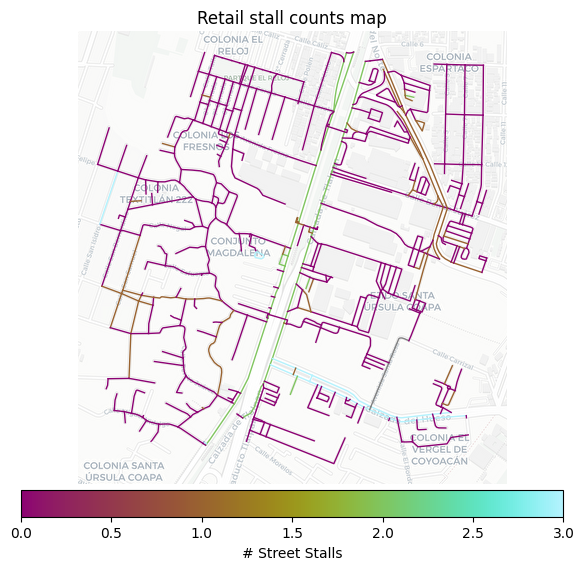

In [37]:
from alivestreets.visualization.map_visualizer import MapVisualizer
import cmcrameri.cm as cmc
map_visualizer = MapVisualizer()
map_visualizer.initialize_map(figsize = (7,7))
map_visualizer.add_street_sampler(
    street_sampler,
    "street_stall_count",
    cmap = cmc.hawaii,
    variable_type = "continuous"
)

map_visualizer.draw_networks(
    colorbar_label = "# Street Stalls",
    colorbar_orientation = "horizontal",
)

map_visualizer.add_basemap(
    alpha = 0.7
)
map_visualizer.finalize_map(
    title="Retail stall counts map"
)